<a href="https://colab.research.google.com/github/JuanBogota/ARSW-2026-02-ParcialPrimerCorte/blob/main/Actividad_Sesion7_Aprendizaje_Estadistico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad Sesión 7 — Aprendizaje Estadístico
## Predicción del precio de vivienda — King County House Sales (Seattle, WA)

**Curso:** Aprendizaje Estadístico — Maestría en Informática, Escuela Colombiana de Ingeniería Julio Garavito
**Estudiantes:** Juan Daniel Bogotá y Jeisson David Sánchez Gómez

Este notebook desarrolla el ciclo completo de preparación de datos, modelado de regresión lineal múltiple y selección de modelo sobre el dataset de ventas de vivienda del condado de King (Seattle, WA, 2014–2015), siguiendo la lógica de CRISP-DM revisada en clase.


In [91]:
# Librerías generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Modelado
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [92]:
df_raw = pd.read_csv('kc_house_data.csv')
df = df_raw.copy()
df.shape

(21597, 21)

---
## 1. Básicos de la Preparación de Datos

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     19221 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21597 non-null  object 
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   17755 non-null  float64
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long  

**Conclusiones de `df.info()`:**

- El dataset tiene **21,597 filas y 21 columnas**, sin valores nulos *aparentes* según el conteo de `info()` para la mayoría de columnas, **excepto** `waterfront` (19,221 no nulos), `view` (21,534 no nulos) y `yr_renovated` (17,755 no nulos).
- `date` está tipada como texto (`str`), no como fecha, hay que convertirla a `datetime` para poder analizar tendencias temporales.
- `sqft_basement` también aparece como texto (`str`) en lugar de numérico. Esto es sospechoso porque es un área en pies cuadrados (debería ser `float`/`int`); lo más probable es que contenga algún valor no numérico.
- El resto de variables numéricas (`price`, `bedrooms`, `bathrooms`, `sqft_living`, `sqft_lot`, `floors`, `condition`, `grade`, `sqft_above`, `yr_built`, `zipcode`, `lat`, `long`, `sqft_living15`, `sqft_lot15`) están correctamente tipadas como `int64` o `float64`.
- `waterfront`, `view` y `condition`/`grade` son variables ordinales/categóricas codificadas como números, aunque estén como `float64`/`int64`, deben tratarse como categóricas en el análisis, no como continuas puras.
- `zipcode` es numérico pero es **categórico**, no debe usarse como variable continua en el modelo de regresión.


In [94]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0]
print(nulos)
print()
print((nulos / len(df) * 100).round(2).astype(str) + ' %')

waterfront      2376
view              63
yr_renovated    3842
dtype: int64

waterfront       11.0 %
view             0.29 %
yr_renovated    17.79 %
dtype: object


**Sobre los valores faltantes:**

- `waterfront`: 2,376 nulos (11%). Al ser una variable binaria muy desbalanceada, es razonable imputar los nulos con la moda (0 = sin vista al agua), ya que es la categoría dominante y una imputación con 0 introduce un sesgo mínimo.
- `view`: 63 nulos (0.3%). Se imputa también con la moda (0 = sin vista), dado el bajo porcentaje de nulos.
- `yr_renovated`: 3,842 nulos (17.8%). Aquí la variable en sí ya tiene una gran mayoría de ceros, por lo que interpretamos el nulo como "sin información de renovación" y lo imputamos también con 0, asumiendo que no se registró una renovación.


In [95]:
print("sqft_basement — valores únicos (muestra):")
print(df['sqft_basement'].unique()[:15])
print()
print("Cantidad de '?':", (df['sqft_basement'] == '?').sum())

sqft_basement — valores únicos (muestra):
['0.0' '400.0' '910.0' '1530.0' '?' '730.0' '1700.0' '300.0' '970.0'
 '760.0' '720.0' '700.0' '820.0' '780.0' '790.0']

Cantidad de '?': 454


`sqft_basement` contiene el símbolo `'?'` como marcador de dato faltante. Como sabemos que `sqft_above + sqft_basement = sqft_living`, podemos reconstruir estos valores faltantes en vez de imputarlos con una medida de tendencia central, lo cual es más preciso.


In [96]:
df['sqft_basement'] = df['sqft_basement'].replace('?', np.nan).astype(float)

# Verificación de la identidad sqft_above + sqft_basement = sqft_living
check = df.dropna(subset=['sqft_basement'])
diff = (check['sqft_above'] + check['sqft_basement'] - check['sqft_living']).abs()
print("Máxima diferencia observada:", diff.max())

# Reconstrucción de sqft_basement faltante a partir de la identidad
mask = df['sqft_basement'].isna()
df.loc[mask, 'sqft_basement'] = df.loc[mask, 'sqft_living'] - df.loc[mask, 'sqft_above']

# Imputación del resto de nulos
df['waterfront'] = df['waterfront'].fillna(0)
df['view'] = df['view'].fillna(0)
df['yr_renovated'] = df['yr_renovated'].fillna(0)

# Conversión de fecha
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')

print(df.isna().sum().sum(), "valores nulos restantes")

Máxima diferencia observada: 0.0
0 valores nulos restantes


In [97]:
num_cols = ['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors',
            'sqft_above','sqft_basement','yr_built','yr_renovated',
            'lat','long','sqft_living15','sqft_lot15']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,21597.0,540296.573506,367368.140101,78000.0000,322000.0000,450000.0000,645000.000,7.700000e+06
bedrooms,21597.0,3.373200,0.926299,1.0000,3.0000,3.0000,4.000,3.300000e+01
bathrooms,21597.0,2.115826,0.768984,0.5000,1.7500,2.2500,2.500,8.000000e+00
sqft_living,21597.0,2080.321850,918.106125,370.0000,1430.0000,1910.0000,2550.000,1.354000e+04
sqft_lot,21597.0,15099.408760,41412.636876,520.0000,5040.0000,7618.0000,10685.000,1.651359e+06
floors,21597.0,1.494096,0.539683,1.0000,1.0000,1.5000,2.000,3.500000e+00
sqft_above,21597.0,1788.596842,827.759761,370.0000,1190.0000,1560.0000,2210.000,9.410000e+03
sqft_basement,21597.0,291.725008,442.667800,0.0000,0.0000,0.0000,560.000,4.820000e+03
yr_built,21597.0,1970.999676,29.375234,1900.0000,1951.0000,1975.0000,1997.000,2.015000e+03
yr_renovated,21597.0,68.758207,364.037499,0.0000,0.0000,0.0000,0.000,2.015000e+03


**Conclusiones de `describe()` sobre las numéricas:**

- `price`: media ≈ USD 540,300, mediana claramente menor que la media y máximo de USD 7.7M → distribución con **sesgo positivo fuerte** (cola larga hacia precios altos), típico de variables de precio.
- `bedrooms`: la mayoría de casas tiene entre 2 y 5 habitaciones, pero el **máximo es 33**, un valor claramente atípico para una vivienda residencial normal, puede ser un outlier o error de captura.
- `sqft_lot` y `sqft_lot15`: la diferencia entre la mediana y el máximo (hasta 1.65 millones de pies²) es enorme, hay lotes atípicamente grandes (posiblemente terrenos rurales dentro del set), fuerte asimetría positiva.
- `bathrooms` toma valores fraccionarios porque cuenta medios baños, puede ser correcto.
- `yr_built` va de 1900 a 2015: el dataset cubre viviendas de más de un siglo de antigüedad, apto para el análisis de tendencia temporal solicitado.
- `lat`/`long` tienen rangos muy acotados (todas las viviendas están en el área de Seattle), consistentes con las coordenadas geográficas de Seattle.


In [98]:
cat_cols = ['bedrooms','bathrooms','floors','waterfront','view','condition','grade']
for c in cat_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts().sort_index())
    print()

--- bedrooms ---
bedrooms
1      196
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

--- bathrooms ---
bathrooms
0.50       4
0.75      71
1.00    3851
1.25       9
1.50    1445
1.75    3048
2.00    1930
2.25    2047
2.50    5377
2.75    1185
3.00     753
3.25     589
3.50     731
3.75     155
4.00     136
4.25      79
4.50     100
4.75      23
5.00      21
5.25      13
5.50      10
5.75       4
6.00       6
6.25       2
6.50       2
6.75       2
7.50       1
7.75       1
8.00       2
Name: count, dtype: int64

--- floors ---
floors
1.0    10673
1.5     1910
2.0     8235
2.5      161
3.0      611
3.5        7
Name: count, dtype: int64

--- waterfront ---
waterfront
0.0    21451
1.0      146
Name: count, dtype: int64

--- view ---
view
0.0    19485
1.0      330
2.0      957
3.0      508
4.0      317
Name: count, dtype: int64

--- condition ---
condition
1       29
2      170
3    14020
4 

**Conclusiones de `value_counts()` sobre las categóricas:**

- `waterfront`: extremadamente desbalanceada — solo 146 de 21,597 casas tienen vista al agua. Es una variable rara pero probablemente con alto poder predictivo cuando está presente.
- `view`: la mayoría de casas tiene `view = 0`; los valores 1–4 representan una minoría con distintos niveles de vista.
- `condition`: concentrada en 3 y 4 ; los extremos 1 y 2 son raros (menos de 200 casos combinados).
- `grade`: distribución aproximadamente normal centrada en 7–8, con colas hacia 3–4 (calidad muy baja, rarísima) y 11–13 (lujo, poco común).
- `bedrooms`: confirma el outlier de 33 habitaciones (1 solo caso) y otro caso con 11.
- `floors`: la mayoría de casas tiene 1 o 2 pisos; los valores 2.5 y 3.5 son poco frecuentes.


In [99]:
dup_ids = df['id'].duplicated().sum()
dup_rows = df.duplicated().sum()
print("Filas totalmente duplicadas:", dup_rows)
print("IDs duplicados (misma vivienda vendida más de una vez):", dup_ids)

# Ejemplo de un id repetido
ejemplo_id = df[df['id'].duplicated(keep=False)]['id'].iloc[0]
df[df['id'] == ejemplo_id][['id','date','price','sqft_living','yr_built']]

Filas totalmente duplicadas: 0
IDs duplicados (misma vivienda vendida más de una vez): 177


,id,date,price,sqft_living,yr_built
93,6021501535,2014-07-25,430000.0,1580,1939
94,6021501535,2014-12-23,700000.0,1580,1939


**Duplicados:**

- No hay filas 100% duplicadas (`duplicated()` = 0), pero sí **177 valores de `id` repetidos**. Esto no es un error: corresponde a viviendas que se vendieron **más de una vez** dentro de la ventana 2014–2015 (el `id` identifica la propiedad, no la transacción). Como cada fila es una venta distinta con su propia fecha y a veces su propio precio, **no las eliminamos**: son observaciones legítimas e independientes en el tiempo. Sí las tendremos presentes al interpretar el modelo, ya que introducen una leve correlación entre observaciones de la misma propiedad.

**Outliers detectados y tratamiento:**

- **`bedrooms = 33`**: es un error de captura evidente . Se filtra/excluye del modelado.
- **`sqft_lot` / `sqft_lot15` extremos** (lotes > 500,000 sqft): se conservan pero se documentan como casos probables para transformación logarítmica.
- **`price` en el percentil superior** (>$3M aprox.): no se eliminan, pero quedan señaladas como observaciones que podrían tener una influencia desproporcionada sobre el modelo, y que hay que revisar más adelante cuando analicemos los residuos.


In [100]:
df = df[df['bedrooms'] < 30].reset_index(drop=True)
print("Filas tras remover outlier de bedrooms:", df.shape[0])

Filas tras remover outlier de bedrooms: 21596


---
## 2. Perfilado y Transformación de Datos

**Variable objetivo (y):** `price`

**Variables predictoras posibles (X):** `bedrooms`, `bathrooms`, `sqft_living`, `sqft_lot`, `floors`, `waterfront`, `view`, `condition`, `grade`, `sqft_above`, `sqft_basement`, `yr_built`, `yr_renovated`, `sqft_living15`, `sqft_lot15`, además de las derivadas de `zipcode`/`lat`/`long` (ubicación) y `date` (tiempo de venta).


In [101]:
target = 'price'
predictors_num = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors',
                   'sqft_above','sqft_basement','yr_built','yr_renovated',
                   'sqft_living15','sqft_lot15']
predictors_cat = ['waterfront','view','condition','grade']
predictors_num + predictors_cat

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'sqft_living15',
 'sqft_lot15',
 'waterfront',
 'view',
 'condition',
 'grade']

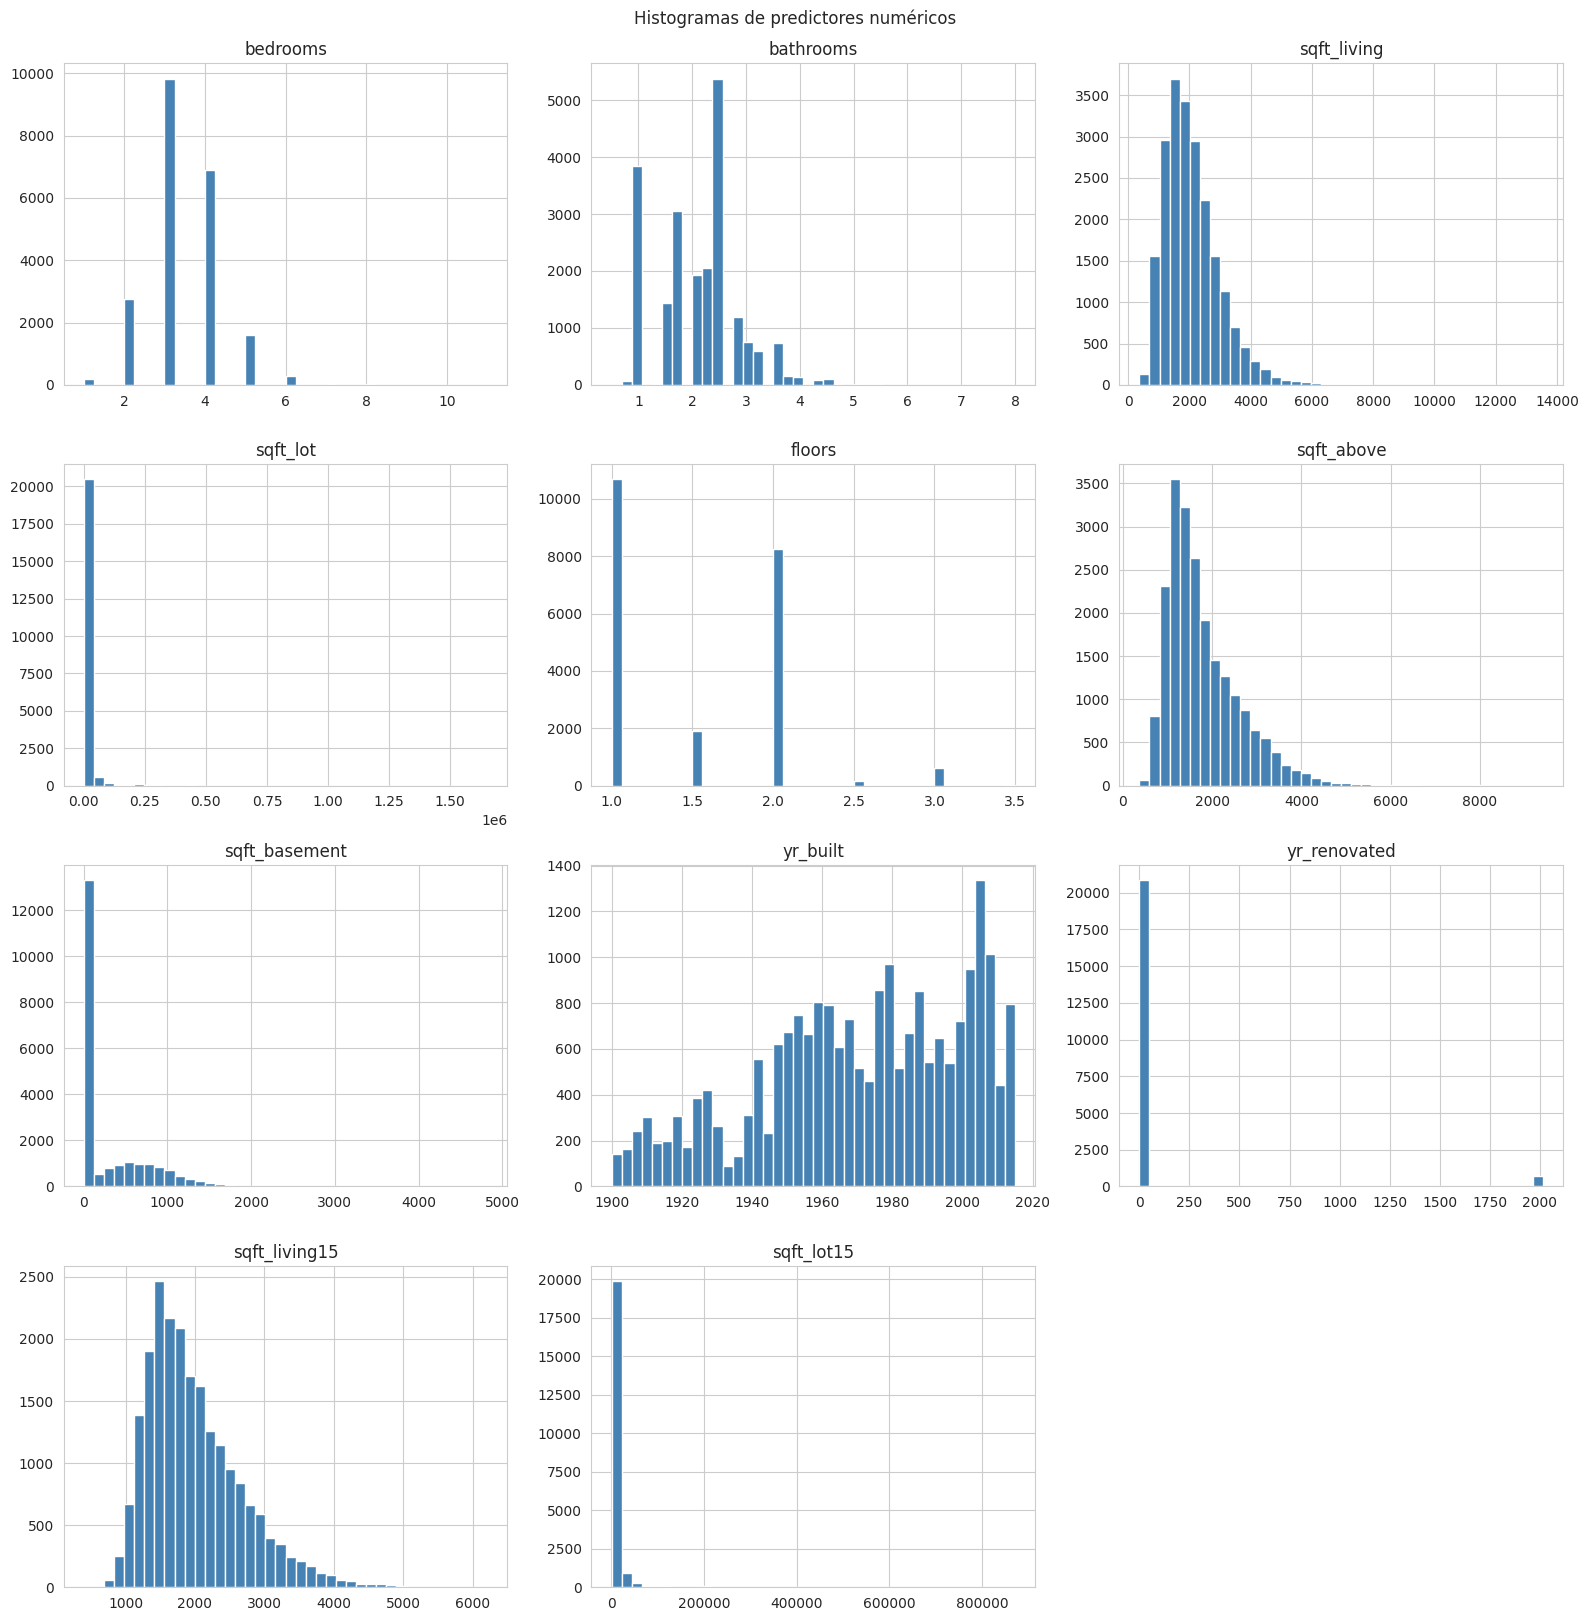

In [102]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(predictors_num):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Histogramas de predictores numéricos', y=1.01)
plt.show()

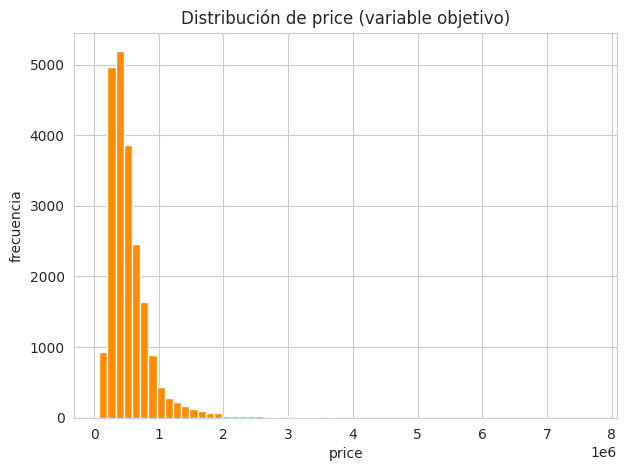

Asimetría de price: 4.023


In [103]:
plt.figure(figsize=(7,5))
plt.hist(df['price'], bins=60, color='darkorange', edgecolor='white')
plt.title('Distribución de price (variable objetivo)')
plt.xlabel('price'); plt.ylabel('frecuencia')
plt.show()

print("Asimetría de price:", df['price'].skew().round(3))

**Distribuciones y sesgo:**

- `price` presenta una **asimetría positiva fuerte** (>4), con una larga cola de viviendas caras. Esto viola el supuesto de normalidad de los residuos si se modela sin transformar, es la principal candidata a transformación logarítmica.
- `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_lot15` y `sqft_living15` también muestran sesgo positivo marcado (son áreas físicas, siempre positivas y con colas largas hacia propiedades grandes).
- `bedrooms` y `bathrooms` se comportan casi como discretas/categóricas con forma aproximadamente simétrica salvo por los outliers ya tratados.
- `yr_built` tiene una distribución más plana, reflejando distintas oleadas de construcción a lo largo del siglo.
- `yr_renovated` está dominada por ceros (la mayoría de casas nunca se ha renovado), más que una variable continua, se comporta como "flag" de renovación.


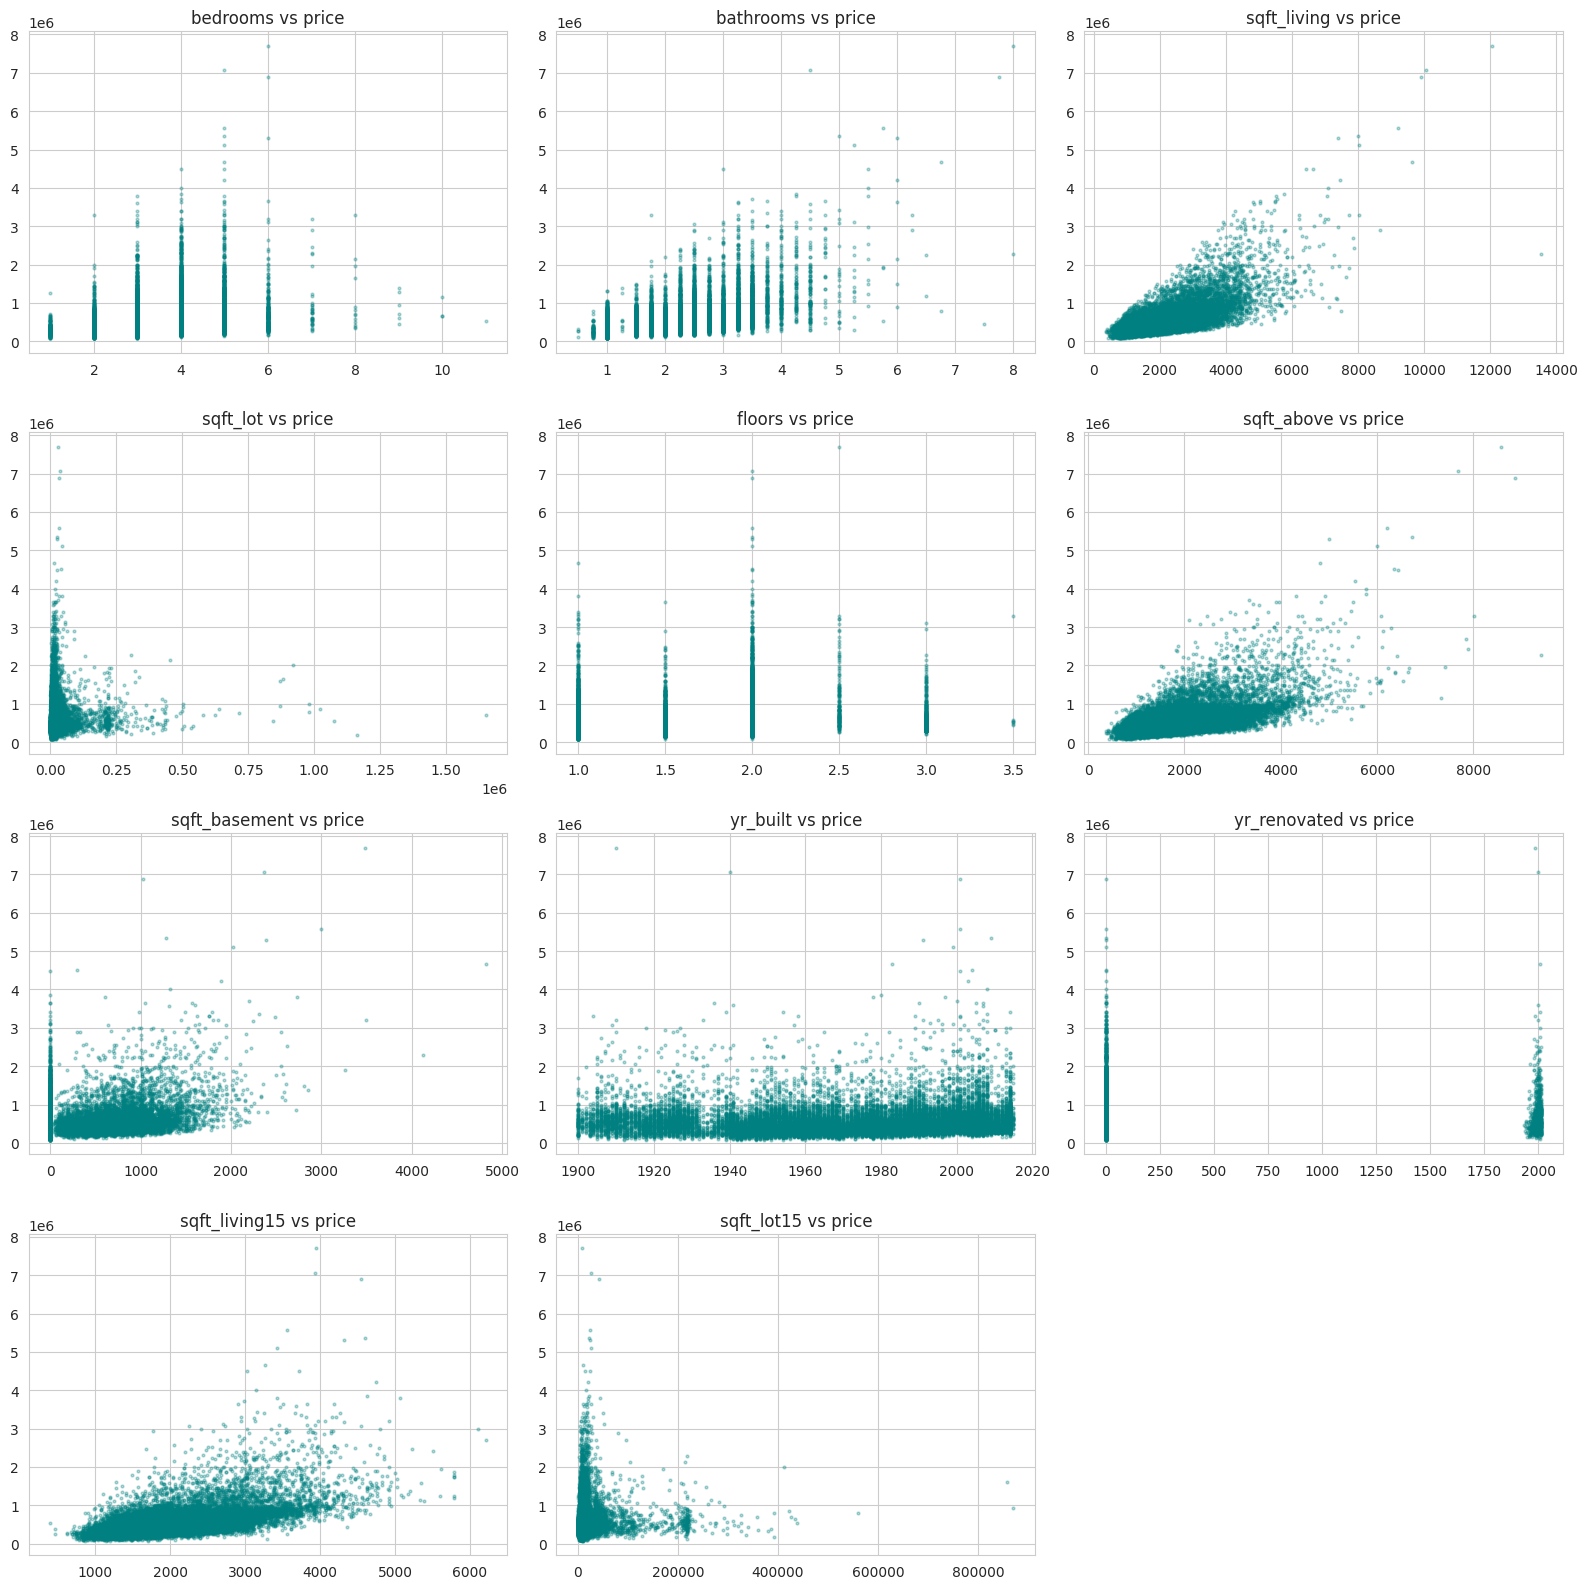

In [104]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(predictors_num):
    axes[i].scatter(df[col], df[target], s=4, alpha=0.3, color='teal')
    axes[i].set_title(f'{col} vs price')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Relaciones lineales (X–y):**

- `sqft_living` y `sqft_living15` muestran la relación lineal positiva más clara y fuerte con `price`.
- `sqft_above` también tiene relación lineal positiva razonable, algo redundante con `sqft_living` (son componentes de la misma medida).
- `bathrooms` y `bedrooms` muestran una relación positiva pero más dispersa (son conteos discretos).
- `sqft_lot` y `sqft_lot15` muestran una nube muy dispersa con poca relación lineal , el efecto del tamaño del lote sobre el precio no es tan directo como el del área construida.
- `yr_built` no muestra relación lineal clara con `price` (prácticamente horizontal), sugiere que la antigüedad por sí sola no predice bien el precio.


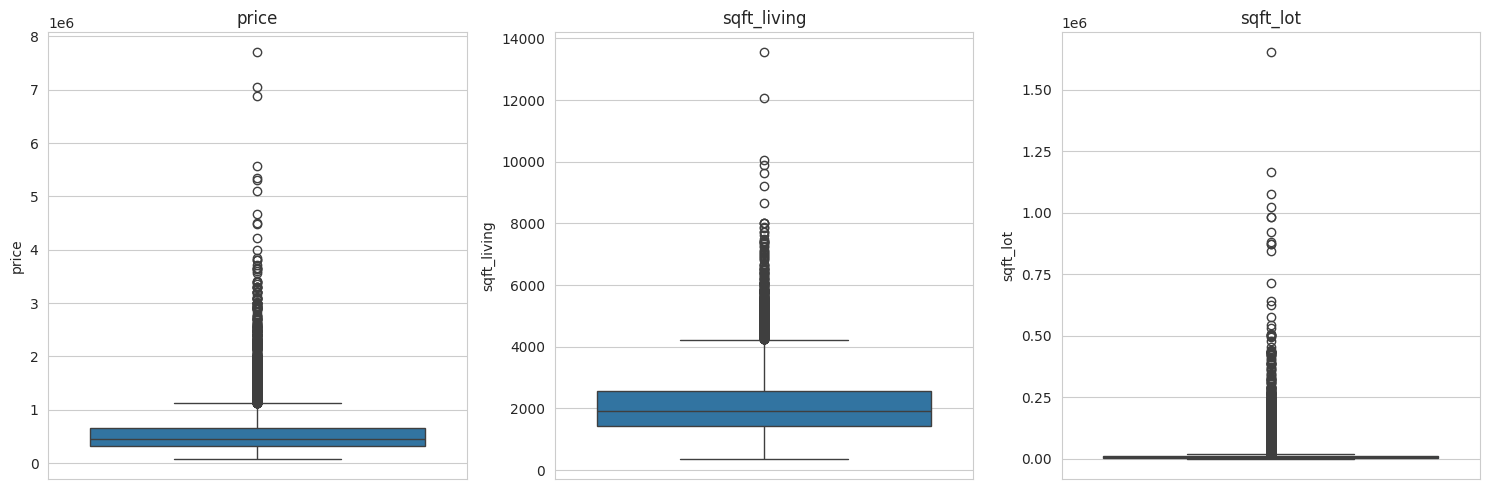

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(y=df['price'], ax=axes[0]); axes[0].set_title('price')
sns.boxplot(y=df['sqft_living'], ax=axes[1]); axes[1].set_title('sqft_living')
sns.boxplot(y=df['sqft_lot'], ax=axes[2]); axes[2].set_title('sqft_lot')
plt.tight_layout()
plt.show()

**Valores atípicos (boxplots):** confirman visualmente lo detectado en `describe()`: `price` y `sqft_lot` tienen numerosos puntos por encima, pero no los eliminamos sistemáticamente porque representan viviendas reales de alto valor, su tratamiento se hará mediante **transformación logarítmica**, que comprime la escala sin descartar información.


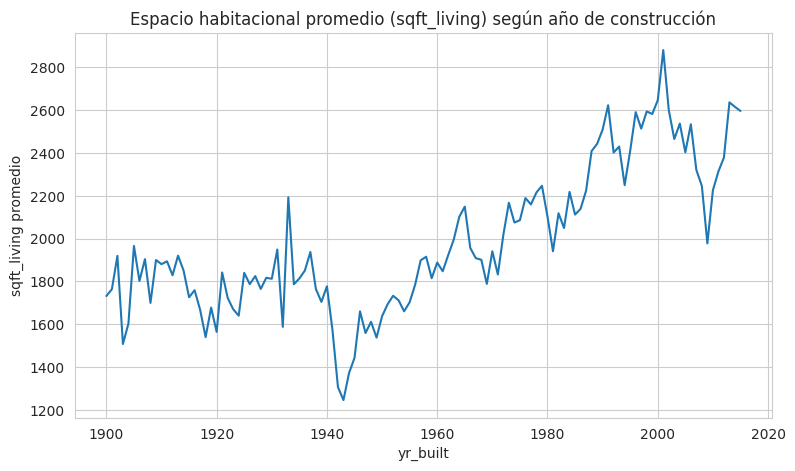

Promedio sqft_living viviendas construidas antes de 1950: 1680.4
Promedio sqft_living viviendas construidas 2000 en adelante: 2472.0


In [106]:
df['yr_sale'] = df['date'].dt.year
avg_living_by_year_built = df.groupby('yr_built')['sqft_living'].mean()

plt.figure(figsize=(9,5))
avg_living_by_year_built.plot()
plt.title('Espacio habitacional promedio (sqft_living) según año de construcción')
plt.xlabel('yr_built'); plt.ylabel('sqft_living promedio')
plt.show()

# Comparación primeras vs últimas décadas del siglo
print("Promedio sqft_living viviendas construidas antes de 1950:",
      round(df[df['yr_built'] < 1950]['sqft_living'].mean(), 1))
print("Promedio sqft_living viviendas construidas 2000 en adelante:",
      round(df[df['yr_built'] >= 2000]['sqft_living'].mean(), 1))

**Tendencia del espacio habitacional a lo largo del tiempo:**

El promedio de `sqft_living` **sí ha aumentado** con el paso del siglo: las viviendas construidas antes de 1950 promedian un área notablemente menor que las construidas desde 2000 en adelante. La serie muestra una tendencia ascendente con fluctuaciones. Esto sugiere que `yr_built`, aunque no tiene relación lineal directa con `price`, sí está correlacionado indirectamente a través de `sqft_living`.


In [107]:
cat_ohe = ['condition','grade']
df_ohe = pd.get_dummies(df, columns=cat_ohe, prefix=cat_ohe, drop_first=True)
print("Columnas nuevas por one-hot de condition/grade:")
print([c for c in df_ohe.columns if c.startswith('condition_') or c.startswith('grade_')])

Columnas nuevas por one-hot de condition/grade:
['condition_2', 'condition_3', 'condition_4', 'condition_5', 'grade_4', 'grade_5', 'grade_6', 'grade_7', 'grade_8', 'grade_9', 'grade_10', 'grade_11', 'grade_12', 'grade_13']


**Codificación one-hot:** aplicamos one-hot encoding a `condition` y `grade` (variables ordinales/categóricas de pocos niveles) para explorar si su efecto sobre el precio es no lineal por categoría. `waterfront` ya es binaria. `zipcode` tiene 70 niveles,se deja para un tratamiento aparte.


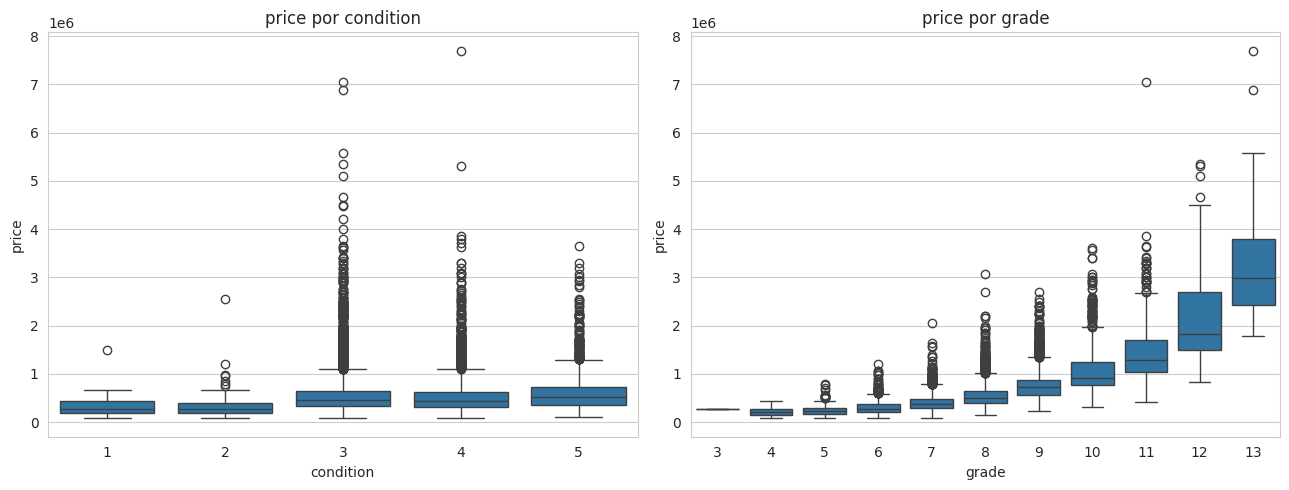

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(x='condition', y='price', data=df, ax=axes[0])
axes[0].set_title('price por condition')
sns.boxplot(x='grade', y='price', data=df, ax=axes[1])
axes[1].set_title('price por grade')
plt.tight_layout()
plt.show()

**Gráficos de precio por categoría:**

- `grade` muestra una relación **muy marcada** con `price`: a mayor calificación de construcción, mayor precio mediano y mayor dispersión en la cola superior, es uno de los predictores categóricos más fuertes.
- `condition` muestra una relación mucho más débil: las viviendas en condición 3 y 4 tienen precios medianos similares a las de condición 5, lo que sugiere que el estado de conservación por sí solo pesa menos que la calidad constructiva (`grade`) o el tamaño.


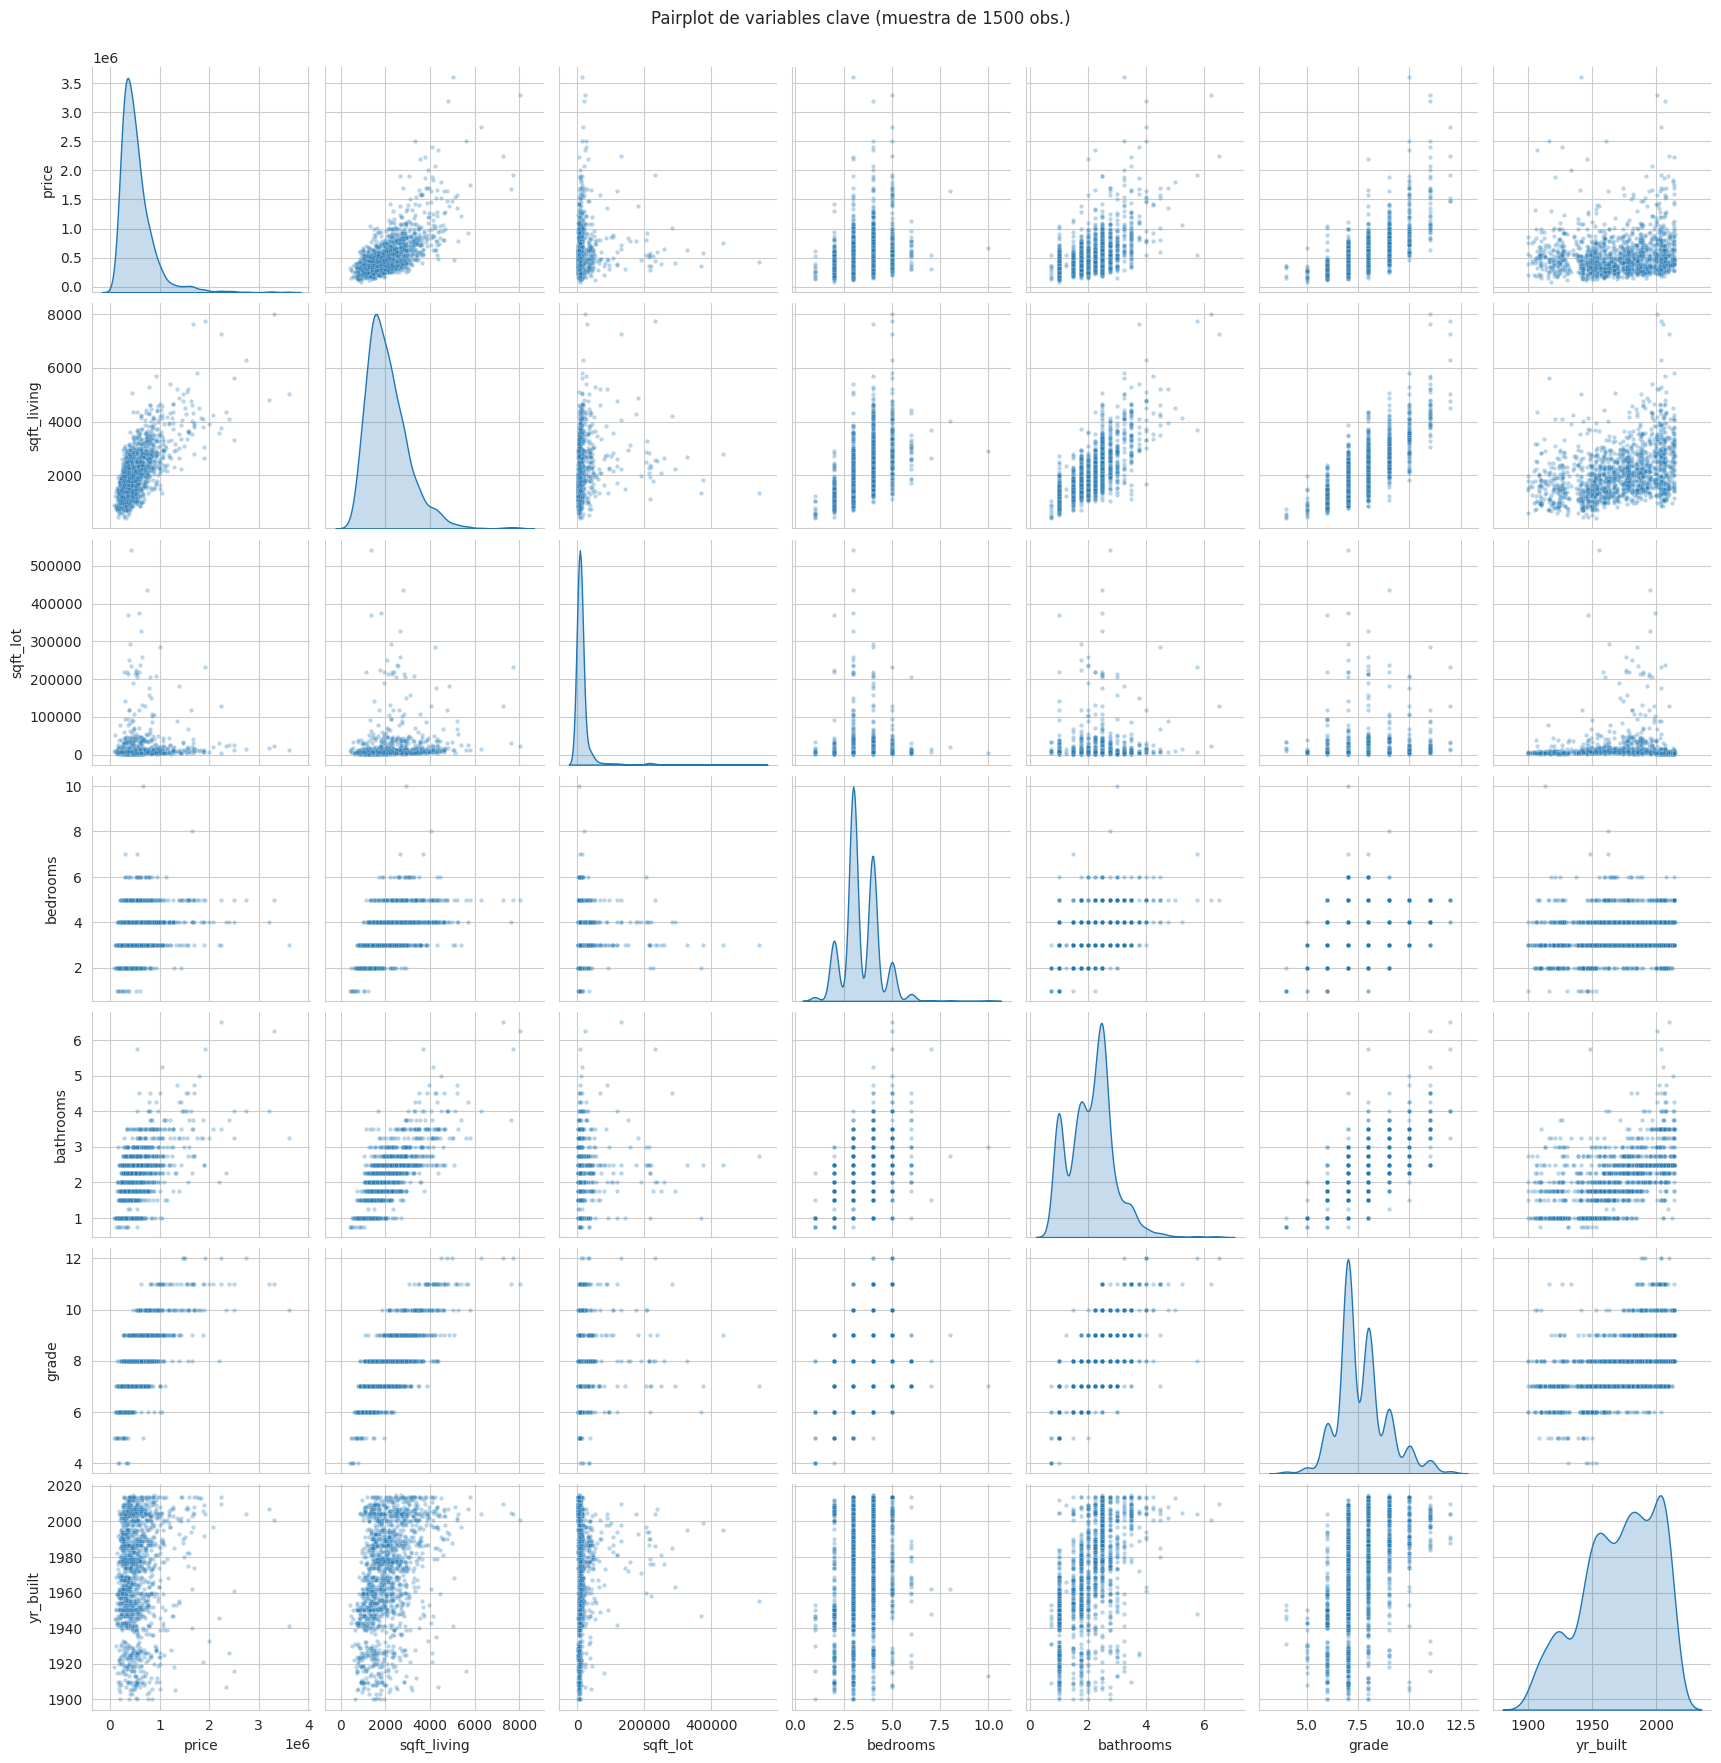

In [109]:
sample_cols = ['price','sqft_living','sqft_lot','bedrooms','bathrooms','grade','yr_built']
sns.pairplot(df[sample_cols].sample(1500, random_state=RANDOM_STATE), diag_kind='kde',
             plot_kws={'alpha':0.3, 's':10})
plt.suptitle('Pairplot de variables clave (muestra de 1500 obs.)', y=1.01)
plt.show()

**Análisis de asociación con pairplot:**

El pairplot confirma la asociación más fuerte y clara entre `price` y `sqft_living`. También se observa una relación positiva entre `sqft_living` y `grade` (las casas más grandes tienden a tener mejor calificación de construcción), lo que anticipa **multicolinealidad** entre estos dos predictores, algo que cuantificamos formalmente en la sección de correlación. `bedrooms`/`bathrooms` muestran nubes escalonadas típicas de variables discretas, con relación positiva pero más débil que `sqft_living`.


---
## 3. Análisis de Correlación

In [110]:
corr_cols = predictors_num + predictors_cat + [target]
corr_matrix = df[corr_cols].corr(method='pearson')

corr_with_price = corr_matrix[target].drop(target).sort_values(ascending=False)
corr_with_price

,price
sqft_living,0.701929
grade,0.667964
sqft_above,0.605392
sqft_living15,0.585267
bathrooms,0.525915
view,0.393502
sqft_basement,0.323794
bedrooms,0.315961
waterfront,0.264308
floors,0.256820


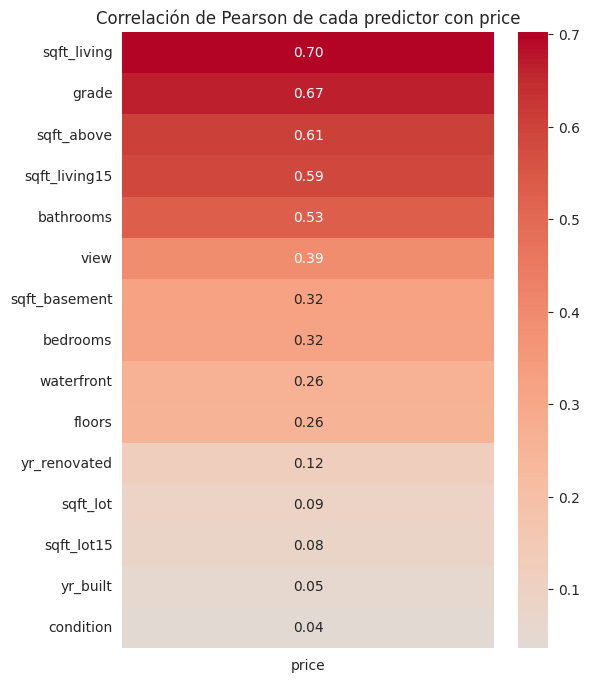

In [111]:
plt.figure(figsize=(6, 8))
sns.heatmap(corr_with_price.to_frame(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlación de Pearson de cada predictor con price')
plt.show()

**Correlación con `price` (Pearson):**

- Los predictores con **mayor correlación positiva** con `price` son `sqft_living`, `grade`, `sqft_above` y `sqft_living15` (todos por encima de 0.6), confirmando que el tamaño construido y la calidad son los factores más determinantes.
- `bathrooms` y `view` muestran correlación moderada positiva (0.3–0.5).
- `bedrooms`, `floors`, `waterfront`, `sqft_lot`, `sqft_lot15`, `yr_renovated` y `condition` tienen correlación **débil** con `price` (< 0.3 ) de forma individual, no implica que no aporten al modelo (pueden tener efecto condicional), pero su fuerza lineal es baja.
- `yr_built` tiene correlación prácticamente nula con `price`, consistente con lo observado en los scatterplots.


In [112]:
full_corr = df[corr_cols].corr(method='pearson')
pairs = (full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))
         .stack()
         .reset_index())
pairs.columns = ['var_1', 'var_2', 'correlacion']
pairs['abs_corr'] = pairs['correlacion'].abs()
pairs = pairs.sort_values('abs_corr', ascending=False).drop(columns='abs_corr')
pairs.head(15)

,var_1,var_2,correlacion
31,sqft_living,sqft_above,0.876448
40,sqft_living,grade,0.762776
35,sqft_living,sqft_living15,0.756400
73,sqft_above,grade,0.756069
15,bathrooms,sqft_living,0.755755
68,sqft_above,sqft_living15,0.731756
48,sqft_lot,sqft_lot15,0.718203
103,sqft_living15,grade,0.713863
41,sqft_living,price,0.701929
18,bathrooms,sqft_above,0.686664


**Multicolinealidad entre predictores:**

Los pares con correlación más alta entre sí (no con `price`) son:

- `sqft_above` – `sqft_living` (muy alta, esperado: `sqft_above` es un componente directo de `sqft_living`).
- `sqft_living` – `sqft_living15` (alta: el área de la vivienda tiende a parecerse a la de sus 15 vecinas más cercanas).
- `sqft_living` – `grade` y `sqft_above` – `grade` (moderada-alta: casas más grandes tienden a tener mejor calificación constructiva).
- `sqft_lot` – `sqft_lot15` (alta, mismo fenómeno de vecindario que con `sqft_living15`).
- `bathrooms` – `sqft_living` (moderada-alta).

**Implicación:** `sqft_above` es casi redundante con `sqft_living` (y con `sqft_basement`, ya que `sqft_above + sqft_basement = sqft_living`), por lo que **no deben incluirse las tres simultáneamente** en el modelo final para evitar colinealidad perfecta/casi perfecta. Esto se confirma más adelante con el Factor de Inflación de Varianza (VIF).


---
## 4. Crear Nuevas Características

### 4.1 Modelo base sin transformaciones

In [113]:
base_preds = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view',
              'condition','grade','sqft_above','sqft_basement','yr_built','yr_renovated',
              'sqft_living15','sqft_lot15']

X_base = sm.add_constant(df[base_preds])
y = df['price']
try:
    model_base = sm.OLS(y, X_base).fit()
    print(model_base.summary())
except Exception as e:
    print("ERROR:", e)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     2925.
Date:                Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:48:23   Log-Likelihood:            -2.9589e+05
No. Observations:               21596   AIC:                         5.918e+05
Df Residuals:                   21581   BIC:                         5.919e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          6.228e+06   1.37e+05     45.482

/tmp/ipykernel_1957/3812647098.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_base = sm.OLS(y, X_base).fit()


**Primer hallazgo importante:** `statsmodels` reporta que la **matriz de diseño es de rango deficiente** (colinealidad perfecta). Esto ocurre porque `sqft_above + sqft_basement = sqft_living` exactamente, son linealmente dependientes. Este es precisamente uno de los supuestos de la regresión (no multicolinealidad perfecta) que se está violando. Retiramos `sqft_above` del modelo base (nos quedamos con `sqft_living` y `sqft_basement`, que ya capturan la misma información sin redundancia perfecta) y reajustamos.


In [114]:
base_preds = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view',
              'condition','grade','sqft_basement','yr_built','yr_renovated',
              'sqft_living15','sqft_lot15']

X_base = sm.add_constant(df[base_preds])
model_base = sm.OLS(y, X_base).fit()
print(model_base.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     2925.
Date:                Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                        02:48:23   Log-Likelihood:            -2.9589e+05
No. Observations:               21596   AIC:                         5.918e+05
Df Residuals:                   21581   BIC:                         5.919e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          6.228e+06   1.37e+05     45.482

In [ ]:
resid_base = model_base.resid
fitted_base = model_base.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
axes[0].scatter(fitted_base, resid_base, s=4, alpha=0.3)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_title('Residuos vs. valores ajustados'); axes[0].set_xlabel('fitted'); axes[0].set_ylabel('residuo')

sm.qqplot(resid_base, line='45', ax=axes[1])
axes[1].set_title('QQ-plot de residuos')

axes[2].hist(resid_base, bins=60, color='slateblue')
axes[2].set_title('Histograma de residuos')
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(resid_base.sample(5000, random_state=RANDOM_STATE))
print(f"Shapiro-Wilk (muestra de 5000): estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.2e}")
print("Asimetría (skew) de los residuos:", round(resid_base.skew(), 3))
print("R² ajustado del modelo base:", round(model_base.rsquared_adj, 4))

**¿Se cumplen los supuestos de la regresión en el modelo base (sin transformar)?**

- **Linealidad/homocedasticidad :** el gráfico de residuos vs. ajustados muestra un claro **patrón en forma de embudo"** (la dispersión de los residuos crece con el valor ajustado), se viola el supuesto de **homocedasticidad**.
- **Normalidad de los errores:** el QQ-plot se desvía notablemente de la línea de 45° en la cola derecha, el histograma muestra una distribución con **sesgo positivo marcado**  (3.0), y la prueba de **Shapiro-Wilk rechaza la normalidad** (p-valor ≈ 0, muy por debajo de 0.05).
- **Conclusión:** el modelo base **no cumple los supuestos** de normalidad ni de homocedasticidad de los residuos, consistente con la fuerte asimetría de `price` observada desde el paso 2. Esto motiva aplicar una transformación logarítmica a la variable objetivo.

### 4.2 Transformación logarítmica

In [ ]:
df['log_price'] = np.log(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].hist(df['price'], bins=60, color='darkorange'); axes[0].set_title('price (original)')
axes[1].hist(df['log_price'], bins=60, color='seagreen'); axes[1].set_title('log(price)')
plt.tight_layout()
plt.show()

print("Skew price:", round(df['price'].skew(),3), " | Skew log_price:", round(df['log_price'].skew(),3))

In [ ]:
y_log = df['log_price']
model_log = sm.OLS(y_log, X_base).fit()

resid_log = model_log.resid
fitted_log = model_log.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
axes[0].scatter(fitted_log, resid_log, s=4, alpha=0.3, color='seagreen')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_title('Residuos vs. ajustados (log price)')

sm.qqplot(resid_log, line='45', ax=axes[1])
axes[1].set_title('QQ-plot residuos (log price)')

axes[2].hist(resid_log, bins=60, color='seagreen')
axes[2].set_title('Histograma residuos (log price)')
plt.tight_layout()
plt.show()

shapiro_stat2, shapiro_p2 = stats.shapiro(resid_log.sample(5000, random_state=RANDOM_STATE))
print(f"Shapiro-Wilk log-modelo: estadístico={shapiro_stat2:.4f}, p-valor={shapiro_p2:.2e}")
print("Asimetría residuos log-modelo:", round(resid_log.skew(), 3))
print("R² ajustado (log_price):", round(model_log.rsquared_adj, 4), " vs. R² ajustado original:", round(model_base.rsquared_adj, 4))

**Efecto de transformar `price` a `log(price)`:**

- La asimetría de los residuos cae drásticamente (de 3.0 a prácticamente 0), y el QQ-plot se ajusta mucho mejor a la línea de 45°.
- La prueba de Shapiro-Wilk **sigue siendo formalmente significativa** (p < 0.05) — algo esperable con más de 20,000 observaciones, donde la prueba es muy sensible a desviaciones mínimas, pero el diagnóstico visual (histograma casi simétrico, QQ-plot mucho más recto) indica una **mejora sustancial y prácticamente relevante** en la normalidad.
- El R² ajustado se mantiene prácticamente igual (0.65), lo cual es esperable: el logaritmo mejora la forma de los errores, no necesariamente el poder explicativo. La ganancia real se aprecia en modelos más interpretables y estables y en menor influencia de outliers de precio.
- **Decisión:** se toma `log(price)` como variable objetivo para el resto del análisis.

### 4.3 Otras transformaciones (predictores)

In [ ]:
# Transformación logarítmica de predictores de área (sesgados) y otras derivadas
df['log_sqft_living'] = np.log(df['sqft_living'])
df['log_sqft_lot'] = np.log(df['sqft_lot'])
df['log_sqft_living15'] = np.log(df['sqft_living15'])
df['log_sqft_lot15'] = np.log(df['sqft_lot15'])

# Edad de la vivienda al momento de la venta (más interpretable que yr_built)
df['house_age'] = df['yr_sale'] - df['yr_built']

# Bandera binaria de renovación (yr_renovated es 0 para la mayoría; el año exacto aporta poco)
df['was_renovated'] = (df['yr_renovated'] > 0).astype(int)

# Término polinómico: la relación grade-price parecía acelerarse en las categorías altas
df['grade_sq'] = df['grade'] ** 2

df[['log_sqft_living','log_sqft_lot','house_age','was_renovated','grade_sq']].describe()

In [ ]:
new_preds = ['bedrooms','bathrooms','log_sqft_living','log_sqft_lot','floors','waterfront','view',
             'condition','grade','grade_sq','house_age','was_renovated',
             'log_sqft_living15','log_sqft_lot15']

X_new = sm.add_constant(df[new_preds])
model_new = sm.OLS(y_log, X_new).fit()
resid_new = model_new.resid

print("R² ajustado — modelo con transformaciones adicionales:", round(model_new.rsquared_adj, 4))
print("R² ajustado — modelo solo con log(price):", round(model_log.rsquared_adj, 4))
print("R² ajustado — modelo base sin transformar:", round(model_base.rsquared_adj, 4))
print()
shapiro_stat3, shapiro_p3 = stats.shapiro(resid_new.sample(5000, random_state=RANDOM_STATE))
print(f"Shapiro-Wilk modelo transformado: estadístico={shapiro_stat3:.4f}, p-valor={shapiro_p3:.2e}")
print("Asimetría residuos:", round(resid_new.skew(), 3))

**Transformaciones probadas y seleccionadas:**

| Transformación | Variable(s) | Justificación | ¿Se conserva? |
|---|---|---|---|
| Logarítmica | `price` → `log_price` | Corrige el sesgo fuerte y la heterocedasticidad detectados en 4.1–4.2 |  Sí |
| Logarítmica | `sqft_living`, `sqft_lot`, `sqft_living15`, `sqft_lot15` | Estas áreas también presentan sesgo positivo ; el log estabiliza su varianza y linealiza su relación con `log_price` |  Sí |
| Derivada (resta) | `yr_built`, `yr_sale` → `house_age` | Más interpretable que el año calendario; permite leer el coeficiente como "efecto por año de antigüedad" |  Sí |
| Binarización | `yr_renovated` → `was_renovated` | Dado que >80% de los valores son 0 y el año exacto de renovación aporta poca variación útil, una bandera binaria es más robusta que la variable continua original |  Sí |
| Polinómica (grado 2) | `grade` → `grade_sq` | Se sospechaba una relación acelerada en la cola alta de `grade` vs. precio  |  Se incluye como candidata, aporta una mejora marginal en R² ajustado — se evalúa su significancia individual en el paso 7 |
| Estandarización  | todas las numéricas | Necesaria antes de comparar magnitudes de coeficientes y para los métodos de regularización/selección — se aplica formalmente en el paso 6, no aquí, para no alterar la interpretación de los coeficientes de este diagnóstico | — |

**Conclusión del paso 4:** el modelo con `log_price` + predictores log-transformados donde correspondía mejora la R² ajustada de forma modesta pero consistente, y sobre todo **mejora sustancialmente el cumplimiento de los supuestos de normalidad y homocedasticidad** de los residuos frente al modelo base sin transformar. Este será el punto de partida para la selección de características.


---
## 5. Seleccionar Características

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(df[new_preds])

vif_data = pd.DataFrame()
vif_data['variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data['variable'] != 'const'].sort_values('VIF', ascending=False)
print(vif_data)

Antes de armar el modelo final, revisamos si hay variables que se están "pisando" entre sí (multicolinealidad), usando el VIF. La regla que manejamos es: si el VIF de una variable es menor a 5 no hay problema, entre 5 y 10 hay que tenerle un ojo encima, y si pasa de 10 es un problema real que toca resolver.

Al calcularlo nos encontramos con algo que tiene mucho sentido: grade salió con un VIF de 90.57 y grade_sq con 86.12, o sea disparadísimos. Esto era esperable porque grade_sq literalmente es grade elevado al cuadrado, entonces las dos variables van a estar súper correlacionadas entre sí casi por definición. El resto de variables no dio ningún problema: lo más alto después de esas dos fue log_sqft_lot con 6.75, y todo lo demás quedó por debajo de eso, la mayoría muy cerca de 1-3.

In [ ]:
df['grade_c'] = df['grade'] - df['grade'].mean()
df['grade_c_sq'] = df['grade_c'] ** 2

In [ ]:
check_preds = [p for p in new_preds if p not in ['grade','grade_sq']] + ['grade_c','grade_c_sq']
X_check = sm.add_constant(df[check_preds])

vif_check = pd.DataFrame()
vif_check['variable'] = X_check.columns
vif_check['VIF'] = [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
vif_check = vif_check[vif_check['variable'] != 'const'].sort_values('VIF', ascending=False)
print(vif_check)

Como grade y grade_sq estaban muy correlacionadas por ser una la versión al cuadrado de la otra, no podíamos simplemente eliminar grade_sq, porque en el paso anterior vimos que sí ayudaba a explicar mejor el precio en las casas de categoría más alta. Lo que hicimos en cambio fue centrar grade (restarle su promedio) antes de elevarla al cuadrado. Esto es un truco típico para estos casos: no cambia lo que el modelo predice ni cómo se interpreta, solo hace que el cálculo del VIF deje de "ver" esa colinealidad artificial.

Y funcionó: después de centrar, el VIF de grade_c bajó de 90.57 a 3.41, y el de grade_c_sq bajó de 86.12 a 1.39. Con esto ya ninguna variable del modelo pasa de VIF = 10, así que de aquí en adelante trabajamos con grade_c y grade_c_sq en vez de las originales.

In [ ]:
# NOTA: el cálculo de zip_price_level se movió a la celda del train_test_split
# (celda siguiente), para calcularlo SOLO con los datos de entrenamiento y evitar
# fuga de información (data leakage) hacia el conjunto de prueba.

Algo que notamos es que hasta ahora el modelo no tiene en cuenta para nada dónde queda ubicada la casa, y en Seattle (como en cualquier ciudad) la zona es un factor gigante en el precio. El problema es que `zipcode` tiene como 70 valores distintos, y si lo metemos directo como dummies se nos llena el modelo de columnas.

Para resolverlo de una forma más simple, se nos ocurrió calcular para cada zipcode el precio promedio (en log) de las casas vendidas ahí, y usar eso como una nueva variable `zip_price_level`. Pero al principio lo hicimos calculando ese promedio con **todo** el dataset antes de partirlo en train/test, y eso es un error de *data leakage* (fuga de datos): el promedio de cada zona terminaría "sabiendo" de antemano los precios de las casas que se supone deben quedar escondidas en el conjunto de prueba.

Para evitarlo, primero separamos train y test, y **solo después** calculamos el promedio de `log_price` por zipcode usando únicamente los datos de entrenamiento. Ese mismo promedio (el de train) se lo pegamos tanto a train como a test, así el test nunca "ve" sus propios precios reflejados en la variable. Si algún zipcode del test no aparece en el train, le ponemos el promedio general de train en vez de dejarlo vacío.

In [ ]:
preds_sin_zip = ['bedrooms','bathrooms','log_sqft_living','log_sqft_lot','floors','waterfront','view',
                 'condition','grade_c','grade_c_sq','house_age','was_renovated',
                 'log_sqft_living15','log_sqft_lot15']

X_train, X_test, y_train, y_test = train_test_split(
    df[preds_sin_zip + ['zipcode']], df['log_price'], test_size=0.2, random_state=RANDOM_STATE
)

# Calculamos el promedio de log_price por zipcode SOLO con el train
zip_means_train = y_train.groupby(X_train['zipcode']).mean()
global_mean_train = y_train.mean()

# Se lo pegamos a train y a test (si un zipcode del test no aparece en train, usamos el promedio general)
X_train['zip_price_level'] = X_train['zipcode'].map(zip_means_train)
X_test['zip_price_level'] = X_test['zipcode'].map(zip_means_train).fillna(global_mean_train)

X_train = X_train.drop(columns='zipcode')
X_test = X_test.drop(columns='zipcode')

final_preds = preds_sin_zip + ['zip_price_level']
print(X_train.shape, X_test.shape)

Con todo lo anterior, esta es la lista de variables que nos quedan para el modelo: `bedrooms`, `bathrooms`, `log_sqft_living`, `log_sqft_lot`, `floors`, `waterfront`, `view`, `condition`, `grade_c`, `grade_c_sq`, `house_age`, `was_renovated`, `log_sqft_living15`, `log_sqft_lot15` y `zip_price_level`. Ninguna quedó con problema de colinealidad después de corregir lo de `grade`, así que decidimos dejarlas todas.

Por último dividimos los datos en un conjunto de entrenamiento (80%) y uno de prueba (20%), usando `random_state=42` para que el resultado sea reproducible y sea el mismo split que hemos venido usando en el resto del notebook. La variable `zip_price_level` se calculó únicamente con los datos de entrenamiento, tal como se explicó arriba, para no filtrar información del test hacia el modelo.

---
## 6. Escalado de Características

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean','std']]

Escogimos `StandardScaler` (dejar cada variable con media 0 y desviación estándar 1) en vez de `MinMaxScaler` o `RobustScaler`. La razón es que ya veníamos aplicando log a las variables más sesgadas (`sqft_living`, `sqft_lot`, etc.) en el Paso 4, así que los outliers extremos ya están bastante controlados y no necesitamos algo tan robusto como `RobustScaler`. Y descartamos `MinMaxScaler` porque comprime todo entre 0 y 1 usando el mínimo y el máximo, lo cual sigue siendo sensible a un dato raro que se nos haya colado. `StandardScaler` es el estándar más razonable para regresión lineal cuando las variables tienen escalas tan distintas entre sí (por ejemplo `bedrooms` va de 1 a 6, pero `zip_price_level` está en escala de log-precio).

Fue importante ajustar (`fit`) el escalador solo con el train y aplicarlo (`transform`) al test, sin volver a ajustarlo, así evitamos otra vez el mismo error de fuga de información que corregimos en el paso anterior.

---
## 7. Construcción del Modelo

Para escoger qué variables usar en el modelo final, usamos las tres estrategias vistas en clase: selección hacia adelante (forward), hacia atrás (backward) y mixta (combinando las dos). Además, en el modelo mixto le agregamos dos términos de interacción para ver si el efecto de una variable cambia según el valor de otra: `log_sqft_living * grade_c` (¿el tamaño pesa más en las casas de mejor calidad?) y `waterfront * view` (¿tener vista al agua y buena vista general se refuerzan entre sí?).

Definimos primero las funciones de selección (las mismas ideas que vimos en la Sesión 5, adaptadas a nuestras variables).

In [ ]:
def forward_selection(data, response, candidates=None):
    remaining = set(candidates) if candidates else set(data.columns) - {response}
    selected = []
    current_score, best_new_score = float('inf'), float('inf')
    while remaining and current_score == best_new_score:
        scores_with_candidates = []
        for candidate in remaining:
            formula = "{} ~ {} + 1".format(response, ' + '.join(selected + [candidate]))
            score = smf.ols(formula, data).fit().aic
            scores_with_candidates.append((score, candidate))
        scores_with_candidates.sort(reverse=True)
        best_new_score, best_candidate = scores_with_candidates.pop()
        if current_score > best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
    formula = "{} ~ {} + 1".format(response, ' + '.join(selected))
    return smf.ols(formula, data).fit(), selected


def backward_selection(data, response, candidates=None):
    selected = list(candidates) if candidates else [c for c in data.columns if c != response]
    formula = "{} ~ {} + 1".format(response, ' + '.join(selected))
    current_score = smf.ols(formula, data).fit().aic
    while len(selected) > 1:
        scores_with_candidates = []
        for candidate in selected:
            reduced = [c for c in selected if c != candidate]
            formula = "{} ~ {} + 1".format(response, ' + '.join(reduced))
            score = smf.ols(formula, data).fit().aic
            scores_with_candidates.append((score, candidate))
        scores_with_candidates.sort()
        best_new_score, worst_candidate = scores_with_candidates[0]
        if best_new_score < current_score:
            selected.remove(worst_candidate)
            current_score = best_new_score
        else:
            break
    formula = "{} ~ {} + 1".format(response, ' + '.join(selected))
    return smf.ols(formula, data).fit(), selected


def stepwise_selection(data, response, candidates=None, threshold_in=0.05, threshold_out=0.10):
    included = []
    pool = list(candidates) if candidates else [c for c in data.columns if c != response]
    while True:
        changed = False
        excluded = [c for c in pool if c not in included]
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_column in excluded:
            formula = "{} ~ {} + 1".format(response, ' + '.join(included + [new_column]))
            model = smf.ols(formula, data).fit()
            new_pval[new_column] = model.pvalues[new_column]
        if not new_pval.empty and new_pval.min() < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
        if included:
            formula = "{} ~ {} + 1".format(response, ' + '.join(included))
            model = smf.ols(formula, data).fit()
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max()
            if worst_pval > threshold_out:
                changed = True
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
        if not changed:
            break
    formula = "{} ~ {} + 1".format(response, ' + '.join(included))
    return smf.ols(formula, data).fit(), included

In [ ]:
# Armamos un solo dataframe de train con las variables escaladas + la variable objetivo,
# porque las funciones de selección trabajan con fórmulas tipo "y ~ x1 + x2 + ..."
train_df = X_train_scaled.copy()
train_df['log_price'] = y_train

# Términos de interacción para probar en el modelo mixto
train_df['log_sqft_living_x_grade_c'] = train_df['log_sqft_living'] * train_df['grade_c']
train_df['waterfront_x_view'] = train_df['waterfront'] * train_df['view']

mixed_candidates = final_preds + ['log_sqft_living_x_grade_c', 'waterfront_x_view']

### Modelo candidato 1 — Selección Forward

In [ ]:
forward_model, forward_vars = forward_selection(train_df, 'log_price', candidates=final_preds)
print("Variables seleccionadas (forward):", forward_vars)
print(forward_model.summary())

El modelo forward terminó incluyendo las 15 variables de `final_preds`, no descartó ninguna. Esto tiene sentido con lo que vimos en el VIF: como ninguna variable tenía colinealidad grave, todas aportan algo al modelo, por poco que sea. El modelo quedó con un R² ajustado de 0.850 y AIC = -5771.4. Las variables con coeficiente más grande (en valor absoluto) son `zip_price_level` (0.264), `log_sqft_living` (0.163) y `grade_c` (0.130), location, tamaño y calidad de construcción son, en ese orden, lo que más mueve el precio.

### Modelo candidato 2 — Selección Backward

In [ ]:
backward_model, backward_vars = backward_selection(train_df, 'log_price', candidates=final_preds)
print("Variables seleccionadas (backward):", backward_vars)
print(backward_model.summary())

El modelo backward llegó exactamente a las mismas 15 variables y los mismos coeficientes que el forward (mismo R² ajustado = 0.850, mismo AIC = -5771.4). Esto es una señal muy buena: no importa si empezamos de cero (forward) o si empezamos con todo y vamos quitando (backward), el resultado converge al mismo modelo. Eso nos da confianza en que este conjunto de variables es estable y no es un artefacto de cómo hicimos la búsqueda.

### Modelo candidato 3 — Selección Mixta (con interacciones)

In [ ]:
mixed_model, mixed_vars = stepwise_selection(train_df, 'log_price', candidates=mixed_candidates)
print("Variables seleccionadas (mixto):", mixed_vars)
print(mixed_model.summary())

El modelo mixto quedó distinto a los otros dos: mantuvo casi todas las variables, pero sacó la variable `waterfront` "cruda" y en su lugar se quedó con la interacción `waterfront_x_view` (tener vista al agua *y* buena vista general, combinadas). También conservó la interacción `log_sqft_living_x_grade_c`, con un coeficiente positivo y muy significativo (0.0267, p < 0.001), esto confirma la sospecha: el tamaño de la casa pesa **más** en el precio cuando la casa además tiene una calidad de construcción alta, no es un efecto que se pueda separar limpiamente.

Este modelo mejoró un poco las métricas: R² ajustado = 0.8505 (vs. 0.8495 de los otros dos) y, sobre todo, un AIC bastante mejor: -5882.8 (vs. -5771.4). Con menos variables "sueltas" pero con las interacciones correctas, el modelo explica más con información más relevante.

### Validación de supuestos de los 3 modelos candidatos

In [ ]:
modelos = {'Forward': forward_model, 'Backward': backward_model, 'Mixto': mixed_model}

for nombre, modelo in modelos.items():
    resid = modelo.resid
    fitted = modelo.fittedvalues

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].scatter(fitted, resid, s=4, alpha=0.3)
    axes[0].axhline(0, color='red', ls='--')
    axes[0].set_title(f'{nombre} — Residuos vs. ajustados')

    sm.qqplot(resid, line='45', ax=axes[1])
    axes[1].set_title(f'{nombre} — QQ-plot')

    axes[2].hist(resid, bins=40, color='slateblue')
    axes[2].set_title(f'{nombre} — Histograma residuos')
    plt.tight_layout()
    plt.show()

    shapiro_stat, shapiro_p = stats.shapiro(resid.sample(min(5000, len(resid)), random_state=RANDOM_STATE))
    print(f"{nombre}: R² ajustado={modelo.rsquared_adj:.4f} | AIC={modelo.aic:.1f} | "
          f"Shapiro p-valor={shapiro_p:.2e} | Asimetría residuos={round(resid.skew(),3)}")
    print()

Para los tres modelos, el patrón es prácticamente igual al que vimos con `log_price` en el Paso 4: la asimetría de los residuos es casi cero (entre -0.045 y -0.068, muy lejos del 3.0 que teníamos sin transformar), y las gráficas de residuos vs. ajustados no muestran el "embudo" que sí veíamos en el modelo base. El Shapiro-Wilk sigue rechazando formalmente la normalidad en los tres (p ≈ 0), pero como ya vimos antes, con más de 17,000 observaciones esta prueba es extremadamente sensible a desviaciones mínimas, el diagnóstico visual (QQ-plot e histograma) importa más aquí que el p-valor.

Comparando los tres: Forward y Backward quedan empatados (R² ajustado = 0.8495, AIC = -5771.4, porque terminaron siendo el mismo modelo), y el mixto los supera un poco en ambos frentes (R² ajustado = 0.8505, AIC = -5882.8, que es menor y por lo tanto mejor). Esto ya nos deja ver que el modelo mixto, con sus interacciones, va a ser el candidato más fuerte.

### Análisis de Varianza (ANOVA) — comparación de los modelos candidatos

In [ ]:
from statsmodels.stats.anova import anova_lm

# Modelo "completo" de referencia: todas las variables + las dos interacciones.
# Como los tres modelos candidatos son subconjuntos de este, podemos compararlos con una prueba F anidada.
full_formula = "log_price ~ {} + 1".format(' + '.join(mixed_candidates))
full_model = smf.ols(full_formula, train_df).fit()

print("--- ANOVA: Forward vs Completo ---")
print(anova_lm(forward_model, full_model))
print()
print("--- ANOVA: Backward vs Completo ---")
print(anova_lm(backward_model, full_model))
print()
print("--- ANOVA: Mixto vs Completo ---")
print(anova_lm(mixed_model, full_model))

Los resultados de la prueba F anidada fueron reveladores:

- **Forward vs. Completo**: F = 57.75, p ≈ 1.01e-25 (mucho menor a 0.05) → sí rechazamos la hipótesis nula. Las variables que le faltan al modelo forward (las dos interacciones) sí aportan información real que el modelo forward se está perdiendo.
- **Backward vs. Completo**: exactamente los mismos números que forward (F = 57.75, p ≈ 1.01e-25), porque backward y forward terminaron siendo el mismo modelo.
- **Mixto vs. Completo**: F = 1.81, p = 0.179 (mayor a 0.05) → no rechazamos la hipótesis nula. Esto quiere decir que el modelo mixto explica prácticamente lo mismo que el modelo completo, aunque le falte la variable `waterfront` cruda (recordemos que el mixto la reemplazó por la interacción `waterfront_x_view`).

**Conclusión de este paso:** el modelo mixto es estadísticamente indistinguible del modelo completo, pero es más simple (no necesita `waterfront` por separado). Y a la vez, es mejor que forward/backward porque esos sí pierden información importante al no incluir las interacciones. Todo apunta a que el **modelo mixto es el mejor candidato** de los tres.

---
## 8. Predicción del Modelo

Ahora usamos el conjunto de prueba (`X_test`/`y_test`), que ningún modelo ha visto todavía, para medir qué tan bien predicen los 3 modelos candidatos. Evaluamos con las 4 métricas que pide la actividad: MAE, MSE, RMSE y R². Primero en la escala de `log_price` (que es como se entrenaron los modelos), y luego "devolviendo" las predicciones a dólares reales (aplicando la exponencial) porque así es más fácil explicarle el error a alguien que no sabe de logaritmos.

In [ ]:
# Armamos el dataframe de test con las mismas columnas que usamos para entrenar (incluidas las interacciones)
test_df = X_test_scaled.copy()
test_df['log_price'] = y_test
test_df['log_sqft_living_x_grade_c'] = test_df['log_sqft_living'] * test_df['grade_c']
test_df['waterfront_x_view'] = test_df['waterfront'] * test_df['view']

resultados = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(test_df)
    mae = mean_absolute_error(test_df['log_price'], y_pred)
    mse = mean_squared_error(test_df['log_price'], y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(test_df['log_price'], y_pred)
    resultados.append({'Modelo': nombre, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

resultados_df = pd.DataFrame(resultados)
resultados_df

In [ ]:
# Mismas métricas, pero traducidas a dólares reales (deshaciendo el log con la exponencial)
resultados_precio = []
for nombre, modelo in modelos.items():
    y_pred_log = modelo.predict(test_df)
    y_pred_price = np.exp(y_pred_log)
    y_true_price = np.exp(test_df['log_price'])
    mae = mean_absolute_error(y_true_price, y_pred_price)
    rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    r2 = r2_score(y_true_price, y_pred_price)
    resultados_precio.append({'Modelo': nombre, 'MAE ($)': mae, 'RMSE ($)': rmse, 'R2': r2})

resultados_precio_df = pd.DataFrame(resultados_precio)
resultados_precio_df

Los resultados sobre el conjunto de prueba confirman lo que ya veníamos viendo:

**En escala log(price):**

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Forward | 0.1552 | 0.2063 | 0.8442 |
| Backward | 0.1552 | 0.2063 | 0.8442 |
| Mixto | 0.1541 | 0.2050 | 0.8460 |

**En dólares reales:**

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Forward | 86,066 | 144,704 | 0.8402 |
| Backward | 86,066 | 144,704 | 0.8402 |
| Mixto | 85,283 | 143,241 | 0.8434 |

El modelo mixto gana en las 3 métricas (aunque por un margen pequeño), y esto es sobre datos de prueba que ningún modelo había visto, o sea que la mejora no es casualidad del ajuste, es una mejora real de capacidad predictiva. En plata: en promedio, el modelo mixto se equivoca por unos 143,241 al predecir el precio de una casa, casi $1,500 menos de error que forward/backward.

---
## 9. Selección del Modelo

Con base en el R² ajustado, el AIC, el ANOVA y las métricas sobre el conjunto de prueba, elegimos el modelo Mixto (con interacciones) como modelo final. Lo elegimos porque tiene el mejor R² ajustado (0.8505) y el menor AIC (-5882.8) de los tres candidatos, el ANOVA confirmó que es estadísticamente equivalente al modelo completo (p = 0.179) a pesar de ser más simple, y además tuvo el mejor desempeño sobre datos de prueba que nunca había visto (RMSE de $143,241 en dólares reales, el más bajo de los tres).

**Explicación para alguien que toma decisiones en el mercado inmobiliario de King County:**

Este modelo nos permite estimar el precio de venta de una vivienda a partir de sus características (tamaño, calidad de construcción, ubicación, antigüedad, vista, etc.) con un margen de error promedio de aproximadamente 143,000. Dicho de otro modo: si el modelo dice que una casa vale 500,000, en la práctica el precio real típicamente cae en algún punto entre 360,000 y 640,000. Esto es útil, por ejemplo, para:

- Un agente inmobiliario que quiere darle a un vendedor un precio de referencia razonable antes de sacar la casa al mercado.
- Un comprador que quiere saber si el precio que le están pidiendo por una casa está en línea con lo que sus características sugieren, o si está sobrevalorada.
- Un banco o inversionista que necesita tasar rápidamente un lote de propiedades.

Los tres factores que más mueven el precio según el modelo son, en este orden: la zona/ubicación (`zip_price_level`), el tamaño de la vivienda(`log_sqft_living`) y la calidad de la construcción (`grade_c`). Además, encontramos algo interesante: el efecto del tamaño sobre el precio es más fuerte en las casas de mejor calidad de construcción, o sea que agregar metros cuadrados a una casa de lujo aumenta el precio proporcionalmente más que agregarlos a una casa de calidad promedio.

**Limitaciones que hay que comunicarle también al negocio:** un margen de error de mas o menos 143,000 es considerable, equivale a cerca del 32% de la mediana de precios (~$450,000), así que este modelo sirve para dar un rango de referencia razonable, no para fijar un precio exacto. El modelo también es lineal (en log), así que asume relaciones relativamente estables entre las variables y el precio; capturamos parte del efecto de la ubicación con `zip_price_level`, pero un modelo con efectos geográficos más sofisticados (por ejemplo, por vecindario en vez de por zipcode completo) probablemente reduciría más ese margen de error.